In [1]:
#Python v3.11.8
#Import necessary packages

import os
import sys

import pandas as pd
import numpy as np

sys.path.append('functions')

from gene_analysis_functions import get_great, get_cistrome, get_pos, insig_nan
from pseudoinverse_functions import pinv_dropmin, quality_filter, trait_cluster

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
'''
Establich cwd, get relevant data, and perform basic formatting
'''

#set directory, import data, drop undefined
os.chdir('/Users/samanderson/Desktop/pellegrini_lab_research/raw_data')
data = pd.read_excel('methylation_phenotype_encoded.xlsx', index_col=0) #mm39
data = data.dropna()

#referring to the point in the data where methylation and phenotype data diverge
sep=55

#seperate trait and methylation data
trait_data = data[:sep]
meth_data = data[sep:]

print(f'{trait_data.shape[0]} traits')

55 traits


In [3]:
#filter trait data to minimize colinearity
filter = 0.5
f_trait_data = quality_filter(trait_data, filter)

print(f'{f_trait_data.shape[0]} traits')

12 traits


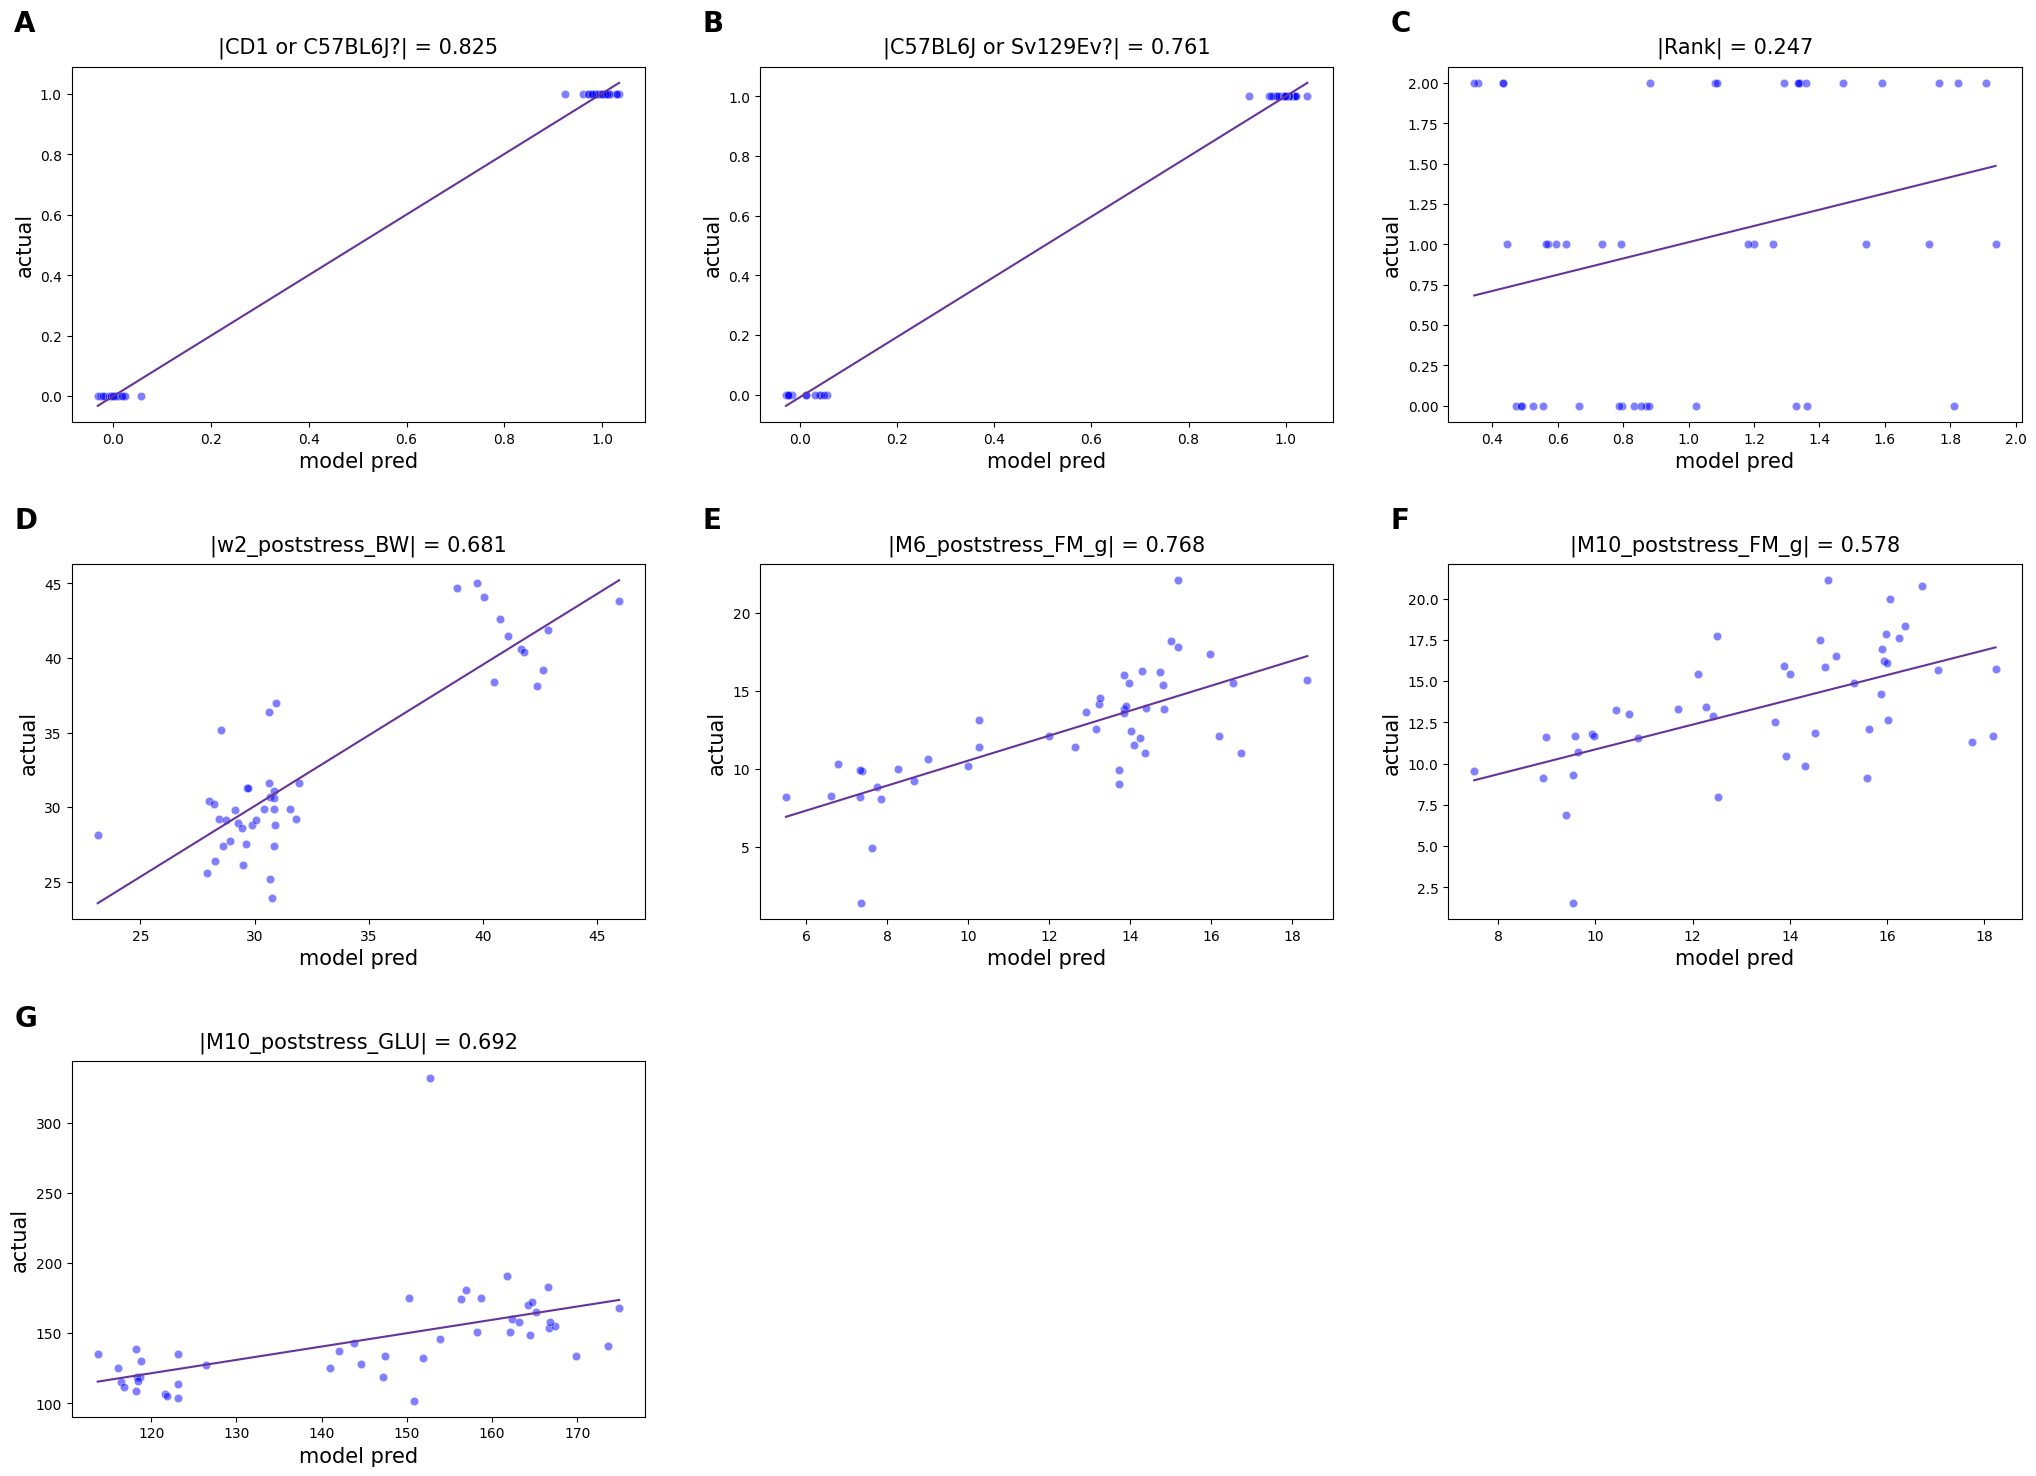

In [4]:
#generate pseudoinversion plots
thresh = 0.5
meth_filter_thresh = 0.5
pinv_dropmin(f_trait_data, meth_data, thresh, 
             find_meth=False, to_filter_meth=True, 
             meth_filter_thresh=meth_filter_thresh);

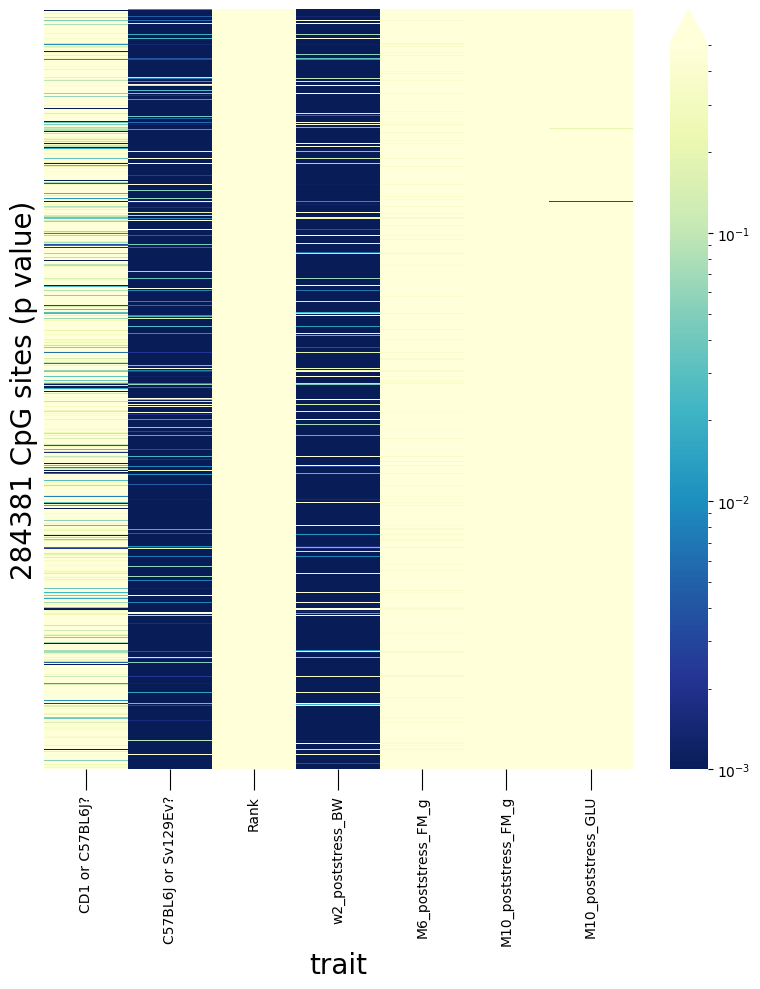

In [5]:
#generate heatmap of probe/trait multivar association p values
thresh = 0.5
meth_filter_thresh = 0.5
trait_vals, trait_pvals, trait_coef = pinv_dropmin(f_trait_data, meth_data, thresh, 
                                                   find_meth=True, plot_results=True, 
                                                   to_filter_meth=False, meth_filter_thresh=meth_filter_thresh);

In [6]:
#identify most significant probes
mm39_data = pd.read_excel('mm39_formatted_manifest.xlsx', index_col=0)
probe_df = get_pos(trait_vals, mm39_data);

/Users/samanderson/Desktop/pellegrini_lab_research/scripts/functions/gene_analysis_functions.py:335: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[column] = np.where(data[column] > 0.01, np.nan, data[column])


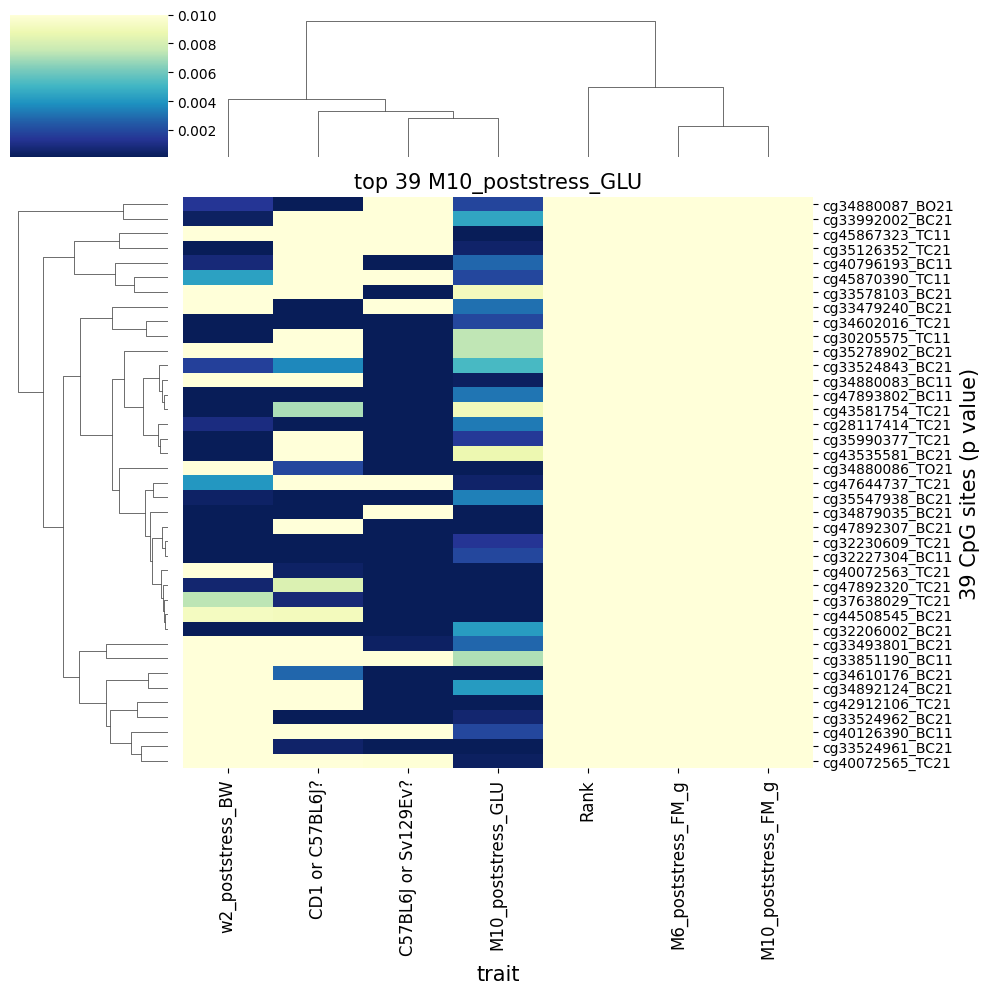

In [7]:
#generate a clustermap of significant probes for selected trait
sig_df = insig_nan(probe_df)
trait = 'M10_poststress_GLU_pval'

temp = sig_df[trait].values
temp = temp[~np.isnan(temp)]
n_probes = len(temp)

trait_cluster(trait_pvals, trait[:-5], n_probes);

In [8]:
#find gene associations of probes via GREAT
probe_df = get_great(probe_df)
probe_df.to_excel('pseudoinverse_probes_unfiltered.xlsx')

print(probe_df)

/Users/samanderson/Desktop/pellegrini_lab_research/scripts/functions/gene_analysis_functions.py:122: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  probe_data['associated_genes'] = gene_by_probes #add gene list to dataframe


                 CD1 or C57BL6J?_pval  CD1 or C57BL6J?_coef  \
index                                                         
cg00101675_BC21                   NaN              0.014361   
cg00116289_BC21                   NaN              0.005293   
cg00211372_TC21                   NaN              0.045866   
cg00531009_BC21                   NaN              0.018367   
cg00747726_TC21                   NaN              0.101403   
...                               ...                   ...   
cg48344138_TC21                   NaN             -0.018640   
cg48344145_TC21              0.008238              0.156888   
cg48344158_BC11                   NaN              0.011600   
cg48344197_BC21                   NaN             -0.019448   
cg48344201_TC11                   NaN              0.048254   

                 C57BL6J or Sv129Ev?_pval  C57BL6J or Sv129Ev?_coef  \
index                                                                 
cg00101675_BC21              2.716820e

                 CD1 or C57BL6J?_pval  CD1 or C57BL6J?_coef  \
index                                                         
cg00101675_BC21                   NaN              0.014361   
cg00116289_BC21                   NaN              0.005293   
cg00211372_TC21                   NaN              0.045866   
cg00531009_BC21                   NaN              0.018367   
cg00747726_TC21                   NaN              0.101403   
...                               ...                   ...   
cg48344138_TC21                   NaN             -0.018640   
cg48344145_TC21              0.008238              0.156888   
cg48344158_BC11                   NaN              0.011600   
cg48344197_BC21                   NaN             -0.019448   
cg48344201_TC11                   NaN              0.048254   

                 C57BL6J or Sv129Ev?_pval  C57BL6J or Sv129Ev?_coef  \
index                                                                 
cg00101675_BC21              2.716820e

/Users/samanderson/Desktop/pellegrini_lab_research/scripts/functions/gene_analysis_functions.py:335: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[column] = np.where(data[column] > 0.01, np.nan, data[column])


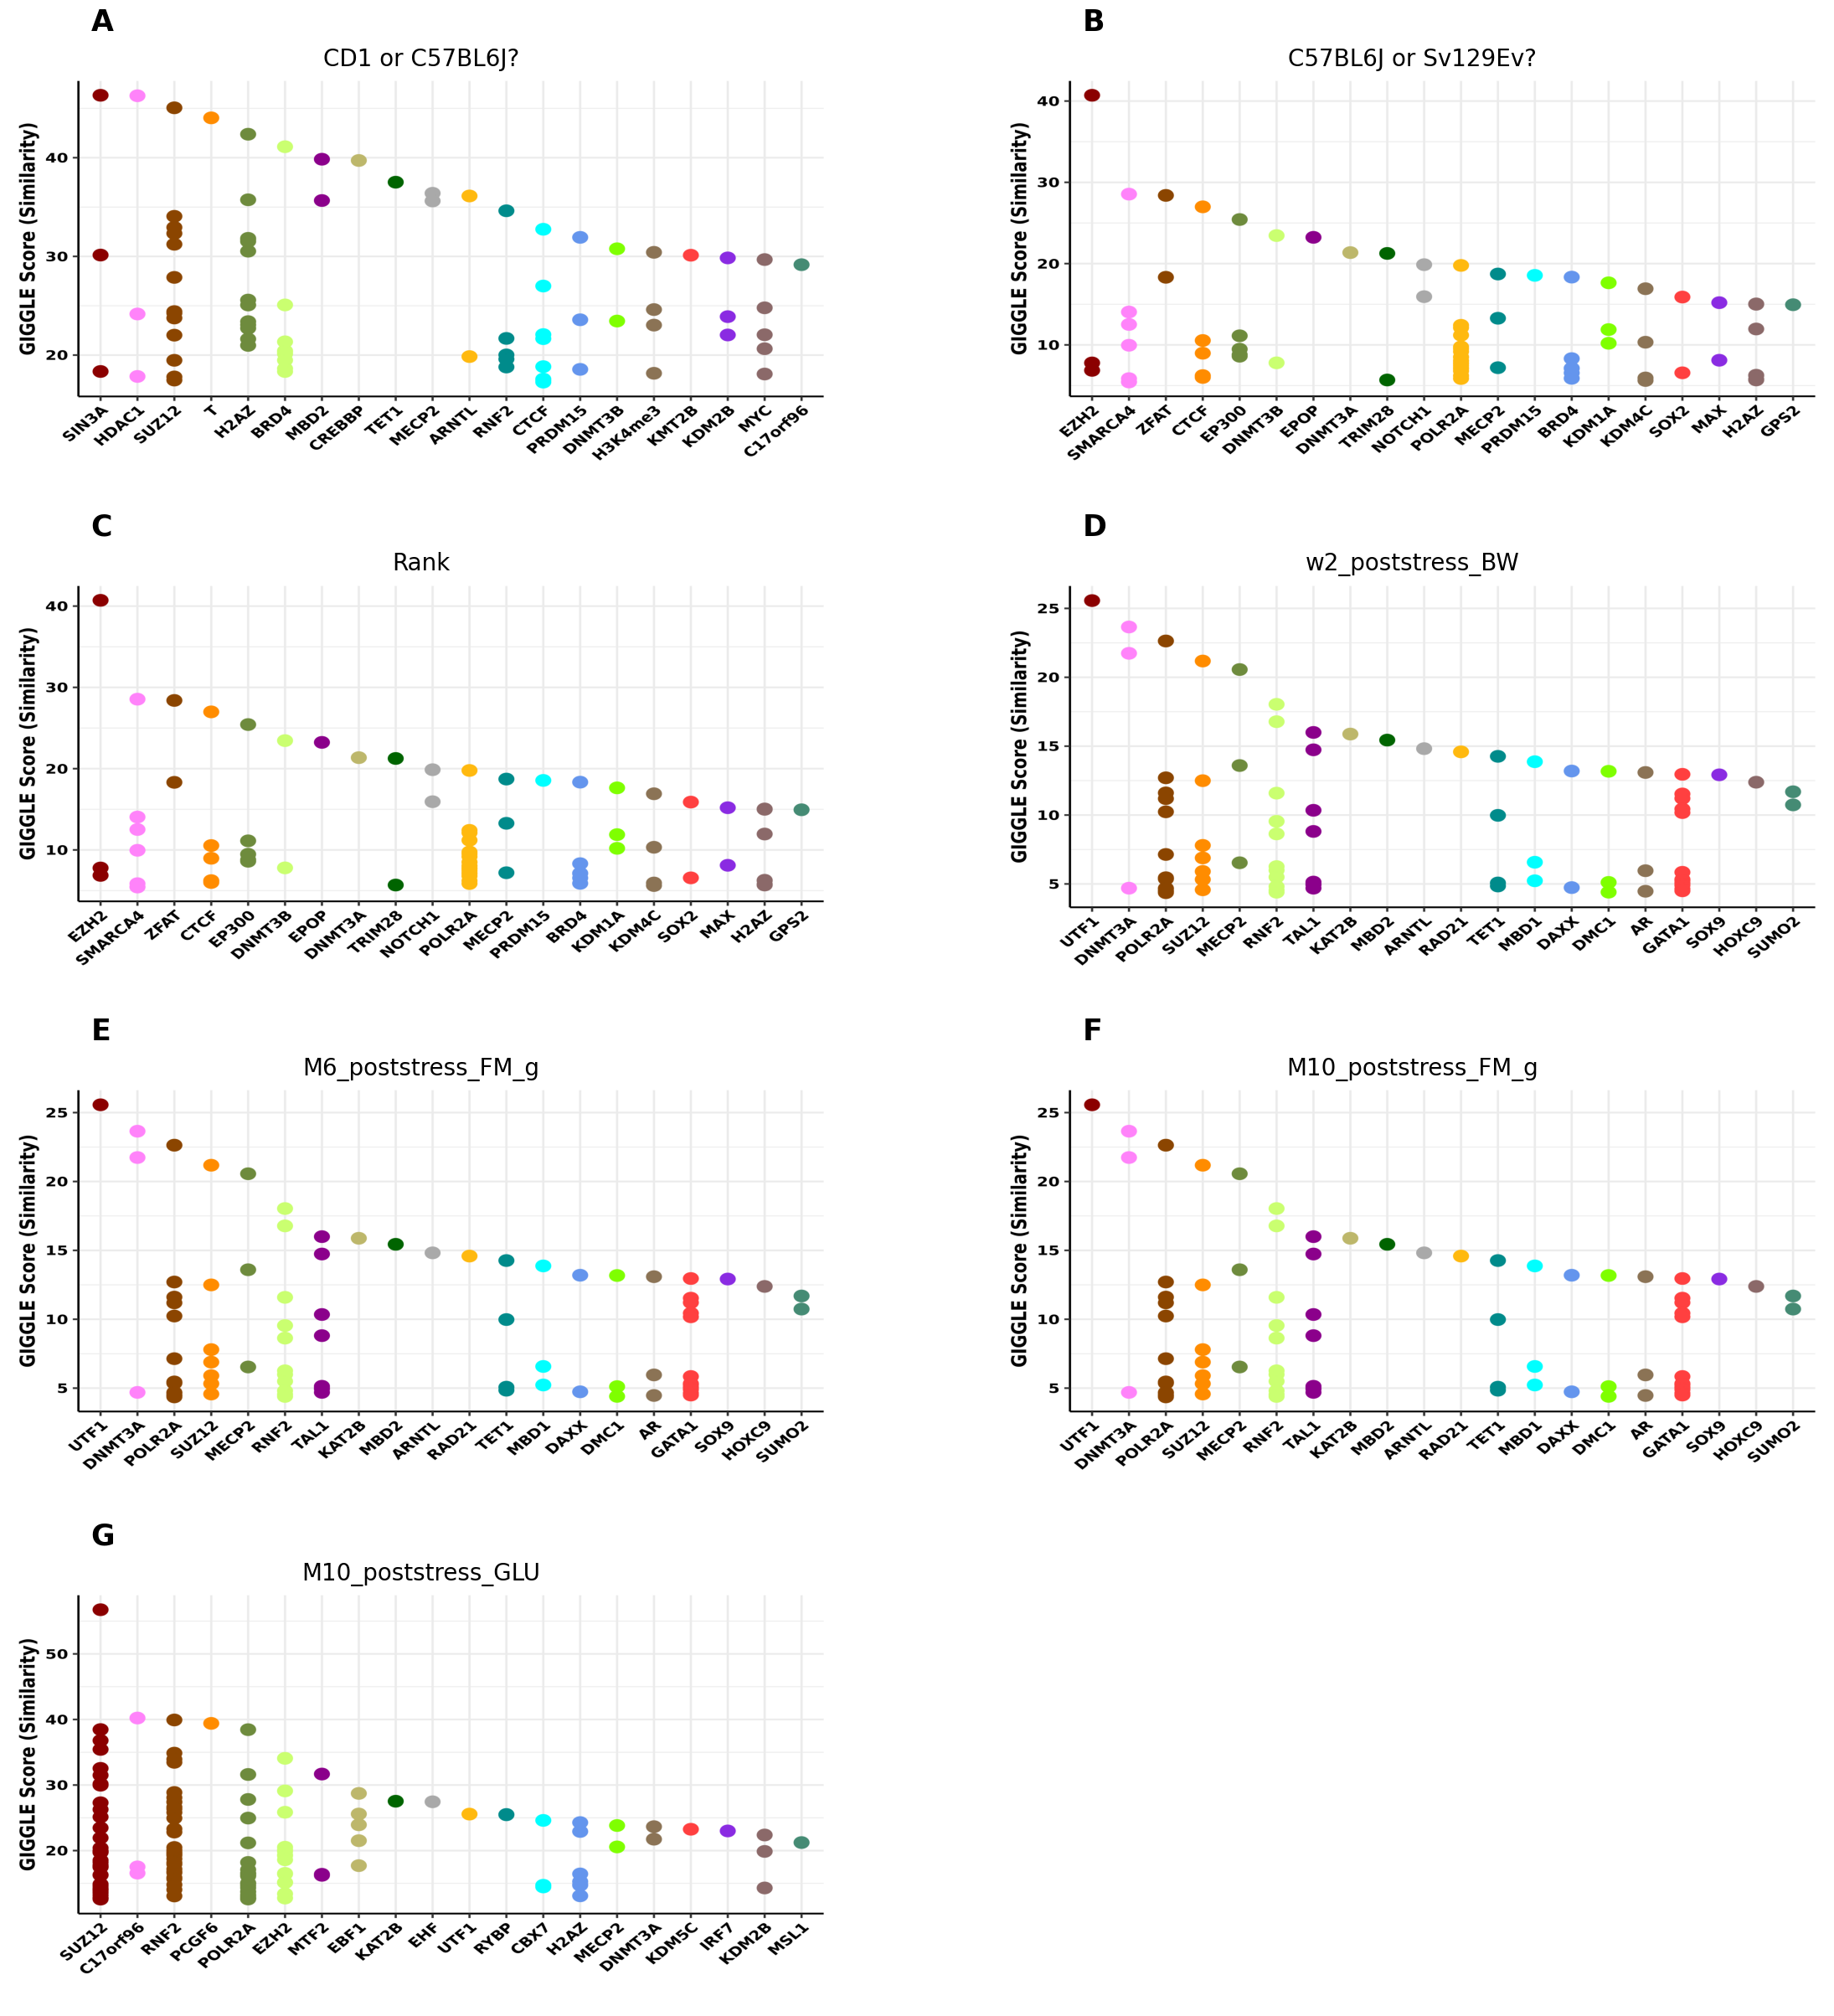

In [9]:
%matplotlib inline

#drop insignificant values
sig_df = insig_nan(probe_df)
print(sig_df)

#this is trial and error, unfortunately 
fig_w = 2800
fig_h = 3000

#generate cistrome plots by trait
get_cistrome(sig_df, fig_w, fig_h)